# Bach Violin Dataset — Timbre Feature Distribution

Extract per-frame timbre features from every audio file in the Bach violin dataset
using `TimbreMetrics.extract_series_from_file`, concatenate all frames into a single
feature matrix, and save it for downstream use (e.g. as a reference distribution for evaluation).

**Output**: `data/processed/bach_violin_timbre_features.parquet` and `.npz`

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
from tqdm.auto import tqdm

PROJECT_ROOT = Path.cwd().parent.parent
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from evaluation.timbre_metrics import TimbreMetrics

print(f"Project root: {PROJECT_ROOT}")

/u/37/thieun1/unix/anaconda3/envs/conda_env3.10/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-04-05 14:34:49.129210: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX_VNNI FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-04-05 14:34:49.217410: I tensorflow/core/util/port.cc:104] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-05 14:34:59.820152: W tensorflow/compiler/xla/stream_executor/pla

Project root: /m/home/home3/37/thieun1/unix/Project/final_project


In [2]:
AUDIO_DIR  = PROJECT_ROOT / "data" / "raw" / "bach-violin" / "audio"
AUDIO_CSV  = PROJECT_ROOT / "data" / "raw" / "bach-violin" / "audio.csv"
OUT_DIR    = PROJECT_ROOT / "data" / "processed"
OUT_DIR.mkdir(parents=True, exist_ok=True)

# TimbreMetrics config
SR             = 16_000
FRAME_WIDTH    = 0.25   # seconds
OVERLAP        = 0.0
FEATURE_TYPES  = ["spectral"]   # or ["spectral", "level", "harmonic"]

print(f"Audio dir: {AUDIO_DIR}  (exists: {AUDIO_DIR.exists()})")
print(f"Audio CSV: {AUDIO_CSV}  (exists: {AUDIO_CSV.exists()})")

Audio dir: /m/home/home3/37/thieun1/unix/Project/final_project/data/raw/bach-violin/audio  (exists: True)
Audio CSV: /m/home/home3/37/thieun1/unix/Project/final_project/data/raw/bach-violin/audio.csv  (exists: True)


## 1. Discover audio files and load metadata

In [3]:
audio_files = sorted(
    [p for p in AUDIO_DIR.rglob("*") if p.suffix.lower() in {".mp3", ".opus", ".wav"}]
)
print(f"Found {len(audio_files)} audio files")

# Load CSV for metadata lookup keyed by filename stem
meta_df = pd.read_csv(AUDIO_CSV)
# Build lookup: filename (no parent path) -> row
meta_lookup = meta_df.set_index("filename").to_dict(orient="index")
print(f"Metadata rows: {len(meta_df)}")
meta_df.head()

Found 29 audio files
Metadata rows: 42


,filename,collection,violinist,work,title,movements,start,end,length,source,license,url
0,emil-telmanyi_bwv1001.mp3,emil-telmanyi,Emil Telmányi,BWV1001,Sonata No. 1 in G minor,4,0:00:03,0:18:04,0:18:01,musopen,PD,https://musopen.org/music/3935-violin-sonata-i...
1,emil-telmanyi_bwv1002.mp3,emil-telmanyi,Emil Telmányi,BWV1002,Partita No. 1 in B minor,8,0:00:00,0:18:01,0:18:01,musopen,PD,https://musopen.org/music/13574-violin-partita...
2,emil-telmanyi_bwv1003.mp3,emil-telmanyi,Emil Telmányi,BWV1003,Sonata No. 2 in A minor,4,0:00:00,0:19:36,0:19:36,musopen,PD,https://musopen.org/music/3936-violin-sonata-n...
3,emil-telmanyi_bwv1004.mp3,emil-telmanyi,Emil Telmányi,BWV1004,Partita No. 2 in D minor,4,0:00:00,0:08:41,0:08:41,musopen,PD,https://musopen.org/music/3786-violin-partita-...
4,emil-telmanyi_bwv1005.mp3,emil-telmanyi,Emil Telmányi,BWV1005,Sonata No. 3 in C major,4,0:00:00,0:22:46,0:22:46,musopen,PD,https://musopen.org/music/3937-violin-sonata-n...


## 2. Extract per-frame features for every file

In [4]:
tm = TimbreMetrics(sample_rate=SR, frame_width_sec=FRAME_WIDTH, overlap_pct=OVERLAP)

all_features: list[dict] = []   # one dict per file: {feat: array, + metadata}
failed: list[str] = []

for path in tqdm(audio_files, desc="Extracting"):
    try:
        series = tm.extract_series_from_file(path, feature_types=FEATURE_TYPES)
    except Exception as e:
        print(f"  SKIP {path.name}: {e}")
        failed.append(path.name)
        continue

    if not series:
        failed.append(path.name)
        continue

    meta = meta_lookup.get(path.name, {})
    all_features.append({
        "filename":   path.name,
        "collection": meta.get("collection", "unknown"),
        "violinist":  meta.get("violinist",  "unknown"),
        "work":       meta.get("work",       "unknown"),
        "series":     series,
        "n_frames":   len(next(iter(series.values()))),
    })

print(f"\nSuccessful: {len(all_features)} / {len(audio_files)}  |  Failed: {len(failed)}")
if failed:
    print("Failed files:", failed)

Extracting: 100%|██████████| 29/29 [00:56<00:00,  1.96s/it]


Successful: 29 / 29  |  Failed: 0


## 3. Concatenate into a flat DataFrame

In [5]:
if not all_features:
    raise RuntimeError("No files were successfully extracted — check errors above.")

# Keep only feature keys present in every file
key_sets = [set(r["series"].keys()) for r in all_features]
common_keys = sorted(set.intersection(*key_sets))
print(f"Features ({len(common_keys)}): {common_keys}")

rows = []
for r in all_features:
    n = r["n_frames"]
    meta_block = pd.DataFrame({
        "filename":   [r["filename"]]   * n,
        "collection": [r["collection"]] * n,
        "violinist":  [r["violinist"]]  * n,
        "work":       [r["work"]]       * n,
    })
    feat_block = pd.DataFrame(
        {k: r["series"][k] for k in common_keys}
    )
    rows.append(pd.concat([meta_block, feat_block], axis=1))

df = pd.concat(rows, ignore_index=True)
print(f"\nDataset shape: {df.shape}  ({df.shape[0]:,} frames x {df.shape[1]} columns)")
df.head()

Features (11): ['mean_center', 'spectral_centroid', 'spectral_crest', 'spectral_decrease', 'spectral_energy', 'spectral_flatness', 'spectral_kurtosis', 'spectral_roll_off', 'spectral_skewness', 'spectral_slope', 'spectral_spread']

Dataset shape: (56132, 15)  (56,132 frames x 15 columns)


,filename,collection,violinist,work,mean_center,spectral_centroid,spectral_crest,spectral_decrease,spectral_energy,spectral_flatness,spectral_kurtosis,spectral_roll_off,spectral_skewness,spectral_slope,spectral_spread
0,emil-telmanyi_bwv1001.mp3,emil-telmanyi,Emil Telmányi,BWV1001,1755.529860,2240.563890,19.053795,-0.023376,7.306432e-08,0.499411,2.551619,6968.7500,0.923848,-3.214474e-07,2295.304946
1,emil-telmanyi_bwv1001.mp3,emil-telmanyi,Emil Telmányi,BWV1001,2414.733909,1581.359841,46.048870,0.008069,2.273752e-03,0.196967,6.032127,4328.1250,1.630816,-4.421514e-07,1430.716393
2,emil-telmanyi_bwv1001.mp3,emil-telmanyi,Emil Telmányi,BWV1001,2467.231991,1528.861759,55.915412,0.007609,6.332870e-03,0.173366,6.237231,4304.6875,1.681169,-4.517641e-07,1400.725879
3,emil-telmanyi_bwv1001.mp3,emil-telmanyi,Emil Telmányi,BWV1001,2437.305875,1558.787875,52.491322,0.010673,8.172690e-03,0.188952,6.033584,4429.6875,1.654779,-4.462845e-07,1435.349249
4,emil-telmanyi_bwv1001.mp3,emil-telmanyi,Emil Telmányi,BWV1001,2433.969376,1562.124374,51.544917,0.008292,7.034816e-03,0.187313,6.247620,4656.2500,1.709188,-4.456735e-07,1453.419333


## 4. Save as CSV

In [6]:
csv_path = OUT_DIR / "bach_violin_timbre_features.csv"

df.to_csv(csv_path, index=False)
print(f"Saved CSV: {csv_path}  ({csv_path.stat().st_size / 1e6:.1f} MB)")
print(f"Shape: {df.shape}")

Saved CSV: /m/home/home3/37/thieun1/unix/Project/final_project/data/processed/bach_violin_timbre_features.csv  (15.0 MB)
Shape: (56132, 15)


## 5. Quick sanity check — feature distributions per violinist

Frames per violinist:


,n_frames
violinist,
Emil Telmányi,25658
John Garner,5058
Karen Gomyo,4664
Kinga Augustyn,2195
Ko Donghwi,4228
MinJi Kim,4413
Oliver Colbentson,3544
Ray Chen,3378
Silei Li,2994



Feature summary (all frames):


,count,mean,std,min,25%,50%,75%,max
mean_center,56132.0,2238.2104,447.6032,-87.6740,1946.8032,2260.2568,2545.1769,3993.4726
spectral_centroid,56132.0,1757.8833,447.6032,2.6212,1450.9168,1735.8370,2049.2906,4083.7678
spectral_crest,56132.0,79.2075,57.8435,2.6639,48.1645,66.6049,94.5203,682.3336
spectral_decrease,56132.0,-0.0578,0.9485,-13.9949,0.0056,0.0074,0.0095,0.1889
spectral_energy,56132.0,0.0065,0.0142,0.0000,0.0007,0.0021,0.0062,0.3041
spectral_flatness,56132.0,0.1606,0.0687,0.0000,0.1173,0.1532,0.1941,0.8370
spectral_kurtosis,56132.0,1261.7095,18484.4523,1.2703,4.2253,5.2728,6.5796,273279.7712
spectral_roll_off,56132.0,4587.9775,908.9232,7.8125,4023.4375,4507.8125,5203.1250,7429.6875
spectral_skewness,56132.0,2.9880,21.8613,-0.2326,1.1868,1.4726,1.7676,324.6261
spectral_slope,56132.0,-0.0000,0.0000,-0.0000,-0.0000,-0.0000,-0.0000,0.0000


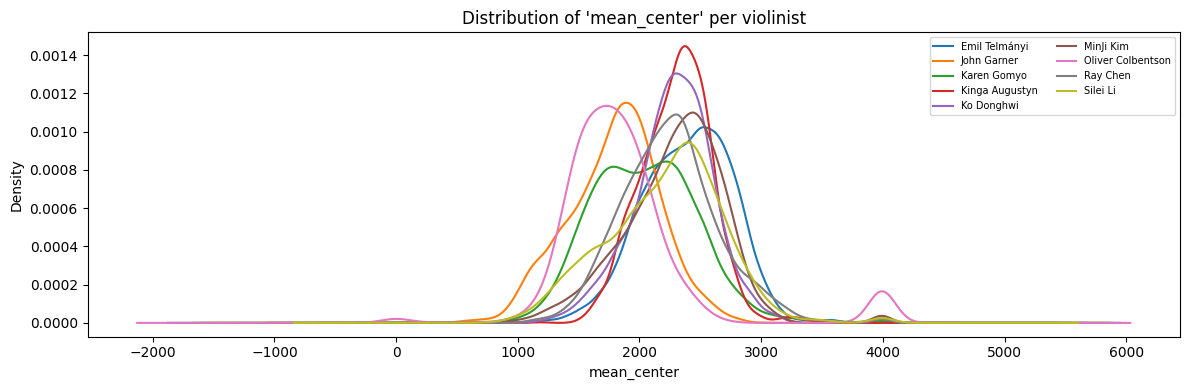

In [7]:
import matplotlib.pyplot as plt

print("Frames per violinist:")
display(df.groupby("violinist").size().rename("n_frames").to_frame())

print("\nFeature summary (all frames):")
display(df[common_keys].describe().T.round(4))

# Distribution plot for spectral_centroid across violinists
plot_feat = common_keys[0]  # first feature
fig, ax = plt.subplots(figsize=(12, 4))
for viol, grp in df.groupby("violinist"):
    grp[plot_feat].plot.kde(ax=ax, label=viol)
ax.set_xlabel(plot_feat)
ax.set_title(f"Distribution of '{plot_feat}' per violinist")
ax.legend(fontsize=7, ncol=2)
plt.tight_layout()
plt.show()